In [45]:
#Membaca dan memuat dataset
import pandas as pd
df = pd.read_csv('berita_kompas_raw.csv')
df

,Judul,Kategori,Link,Tanggal
0,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,Megapolitan,https://megapolitan.kompas.com/read/2026/10/04...,4 Oktober 2026
1,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,Nasional,https://nasional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
2,Eks Kapolda Riau Herry Heryawan Naik Pangkat J...,Regional,https://regional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
3,Operasi Gabungan TNI-Polri Semalam di Majaleng...,Bandung,https://bandung.kompas.com/read/2026/10/04/103...,4 Oktober 2026
4,Heboh IRT Ketahuan Curi Cincin Berlian di Meda...,Regional,https://regional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
...,...,...,...,...
133,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...",Nasional,https://nasional.kompas.com/read/2026/10/03/18...,3 Oktober 2026
134,Bupati Bulungan Percepat Pembangunan Infrastru...,Regional,https://regional.kompas.com/read/2026/10/03/18...,3 Oktober 2026
135,2 Pelajar Terseret Ombak di Pantai Citepus Suk...,Bandung,https://bandung.kompas.com/read/2026/10/03/175...,3 Oktober 2026
136,"Pipa Diduga Bocor Tersenggol Proyek Trotoar, J...",Megapolitan,https://megapolitan.kompas.com/read/2026/10/03...,3 Oktober 2026


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Judul     138 non-null    str  
 1   Kategori  128 non-null    str  
 2   Link      138 non-null    str  
 3   Tanggal   101 non-null    str  
dtypes: str(4)
memory usage: 4.4 KB


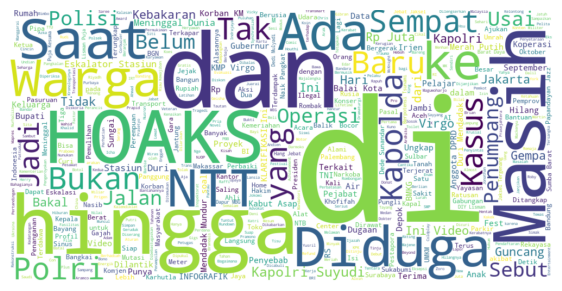

In [47]:
#Visualisasi wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['Judul'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=500).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [48]:
#Remove HTML
import re
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

df['rm_html'] = df['Judul'].apply(remove_html)
df[['Judul','rm_html']]

,Judul,rm_html
0,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,2 Pria Diduga Mesum di Toilet Stasiun Manggara...
1,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...
2,Eks Kapolda Riau Herry Heryawan Naik Pangkat J...,Eks Kapolda Riau Herry Heryawan Naik Pangkat J...
3,Operasi Gabungan TNI-Polri Semalam di Majaleng...,Operasi Gabungan TNI-Polri Semalam di Majaleng...
4,Heboh IRT Ketahuan Curi Cincin Berlian di Meda...,Heboh IRT Ketahuan Curi Cincin Berlian di Meda...
...,...,...
133,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...","BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora..."
134,Bupati Bulungan Percepat Pembangunan Infrastru...,Bupati Bulungan Percepat Pembangunan Infrastru...
135,2 Pelajar Terseret Ombak di Pantai Citepus Suk...,2 Pelajar Terseret Ombak di Pantai Citepus Suk...
136,"Pipa Diduga Bocor Tersenggol Proyek Trotoar, J...","Pipa Diduga Bocor Tersenggol Proyek Trotoar, J..."


In [49]:
#Remove Hashtag
def remove_hashtag(text):
    return re.sub(r'#\w+', '', text)

df['rm_hashtag'] = df['rm_html'].apply(remove_hashtag)
df[['rm_html','rm_hashtag']]

,rm_html,rm_hashtag
0,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,2 Pria Diduga Mesum di Toilet Stasiun Manggara...
1,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...
2,Eks Kapolda Riau Herry Heryawan Naik Pangkat J...,Eks Kapolda Riau Herry Heryawan Naik Pangkat J...
3,Operasi Gabungan TNI-Polri Semalam di Majaleng...,Operasi Gabungan TNI-Polri Semalam di Majaleng...
4,Heboh IRT Ketahuan Curi Cincin Berlian di Meda...,Heboh IRT Ketahuan Curi Cincin Berlian di Meda...
...,...,...
133,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...","BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora..."
134,Bupati Bulungan Percepat Pembangunan Infrastru...,Bupati Bulungan Percepat Pembangunan Infrastru...
135,2 Pelajar Terseret Ombak di Pantai Citepus Suk...,2 Pelajar Terseret Ombak di Pantai Citepus Suk...
136,"Pipa Diduga Bocor Tersenggol Proyek Trotoar, J...","Pipa Diduga Bocor Tersenggol Proyek Trotoar, J..."


In [50]:
#Lower Casing
df['lower_case'] = df['rm_hashtag'].str.lower()
df[['rm_hashtag', 'lower_case']]

,rm_hashtag,lower_case
0,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,2 pria diduga mesum di toilet stasiun manggara...
1,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
2,Eks Kapolda Riau Herry Heryawan Naik Pangkat J...,eks kapolda riau herry heryawan naik pangkat j...
3,Operasi Gabungan TNI-Polri Semalam di Majaleng...,operasi gabungan tni-polri semalam di majaleng...
4,Heboh IRT Ketahuan Curi Cincin Berlian di Meda...,heboh irt ketahuan curi cincin berlian di meda...
...,...,...
133,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...","bgn bakal ""cut off"" yayasan yang pungut setora..."
134,Bupati Bulungan Percepat Pembangunan Infrastru...,bupati bulungan percepat pembangunan infrastru...
135,2 Pelajar Terseret Ombak di Pantai Citepus Suk...,2 pelajar terseret ombak di pantai citepus suk...
136,"Pipa Diduga Bocor Tersenggol Proyek Trotoar, J...","pipa diduga bocor tersenggol proyek trotoar, j..."


In [51]:
#Remove URL
import re
def remove_rls(text):
    text = re.sub(r'https?\/\/S+', '',  str(text)) # remove the hyperlink
    text = re.sub(r'http\S+', '',  str(text)) # remove the hyperlink
    text = re.sub(r'www\S+', '',  str(text)) # remove the www
    text = re.sub(r'\S+@\S+', '', str(text)) # remove the email
    return text

df['rm_url'] = df['lower_case'].apply(remove_rls)
df[['lower_case','rm_url']]

,lower_case,rm_url
0,2 pria diduga mesum di toilet stasiun manggara...,2 pria diduga mesum di toilet stasiun manggara...
1,kapolda ntt irjen rudi darmoko jabat kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
2,eks kapolda riau herry heryawan naik pangkat j...,eks kapolda riau herry heryawan naik pangkat j...
3,operasi gabungan tni-polri semalam di majaleng...,operasi gabungan tni-polri semalam di majaleng...
4,heboh irt ketahuan curi cincin berlian di meda...,heboh irt ketahuan curi cincin berlian di meda...
...,...,...
133,"bgn bakal ""cut off"" yayasan yang pungut setora...","bgn bakal ""cut off"" yayasan yang pungut setora..."
134,bupati bulungan percepat pembangunan infrastru...,bupati bulungan percepat pembangunan infrastru...
135,2 pelajar terseret ombak di pantai citepus suk...,2 pelajar terseret ombak di pantai citepus suk...
136,"pipa diduga bocor tersenggol proyek trotoar, j...","pipa diduga bocor tersenggol proyek trotoar, j..."


In [52]:
#Remove Punctuations
import string
punc = string.punctuation + '"“”‘’'
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', punc))

df['rm_punc'] = df['rm_url'].apply(remove_punctuation)
df[['rm_url','rm_punc']]

,rm_url,rm_punc
0,2 pria diduga mesum di toilet stasiun manggara...,2 pria diduga mesum di toilet stasiun manggara...
1,kapolda ntt irjen rudi darmoko jabat kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
2,eks kapolda riau herry heryawan naik pangkat j...,eks kapolda riau herry heryawan naik pangkat j...
3,operasi gabungan tni-polri semalam di majaleng...,operasi gabungan tnipolri semalam di majalengk...
4,heboh irt ketahuan curi cincin berlian di meda...,heboh irt ketahuan curi cincin berlian di meda...
...,...,...
133,"bgn bakal ""cut off"" yayasan yang pungut setora...",bgn bakal cut off yayasan yang pungut setoran ...
134,bupati bulungan percepat pembangunan infrastru...,bupati bulungan percepat pembangunan infrastru...
135,2 pelajar terseret ombak di pantai citepus suk...,2 pelajar terseret ombak di pantai citepus suk...
136,"pipa diduga bocor tersenggol proyek trotoar, j...",pipa diduga bocor tersenggol proyek trotoar ja...


In [53]:
from mpstemmer import MPStemmer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stemmer = MPStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [54]:
#Stemmer
df['stem'] = df['rm_punc'].apply(lambda x: stemmer.stem_kalimat(x) if isinstance(x, str) else '')
df[['rm_punc','stem']]

,rm_punc,stem
0,2 pria diduga mesum di toilet stasiun manggara...,2 pria duga mesum di toilet stasiun manggarai ...
1,kapolda ntt irjen rudi darmoko jabat kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
2,eks kapolda riau herry heryawan naik pangkat j...,eks kapolda riau herry heryawan naik pangkat j...
3,operasi gabungan tnipolri semalam di majalengk...,operasi gabung tnipolri malam di majalengka si...
4,heboh irt ketahuan curi cincin berlian di meda...,heboh irt tahu curi cincin berlian di medan mo...
...,...,...
133,bgn bakal cut off yayasan yang pungut setoran ...,bgn bakal cut off yayasan yang pungut setor ke...
134,bupati bulungan percepat pembangunan infrastru...,bupati bulungan cepat bangun infrastruktur di ...
135,2 pelajar terseret ombak di pantai citepus suk...,2 pelajar seret ombak di pantai citepus sukabu...
136,pipa diduga bocor tersenggol proyek trotoar ja...,pipa duga bocor senggol proyek trotoar jalan h...


In [55]:
#Remove Stopword
sw = set(stopwords.words('indonesian'))
def remove_stopwords(text):
  return " ".join([word for word in str(text).split() if word not in sw])
df['rm_stopwords'] = df['stem'].apply(remove_stopwords)
df[['stem','rm_stopwords']]

,stem,rm_stopwords
0,2 pria duga mesum di toilet stasiun manggarai ...,2 pria duga mesum toilet stasiun manggarai tan...
1,kapolda ntt irjen rudi darmoko jabat kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...
2,eks kapolda riau herry heryawan naik pangkat j...,eks kapolda riau herry heryawan pangkat komjen...
3,operasi gabung tnipolri malam di majalengka si...,operasi gabung tnipolri malam majalengka sita ...
4,heboh irt tahu curi cincin berlian di medan mo...,heboh irt curi cincin berlian medan modus simp...
...,...,...
133,bgn bakal cut off yayasan yang pungut setor ke...,bgn cut off yayasan pungut setor mitra dapur mbg
134,bupati bulungan cepat bangun infrastruktur di ...,bupati bulungan cepat bangun infrastruktur bun...
135,2 pelajar seret ombak di pantai citepus sukabu...,2 pelajar seret ombak pantai citepus sukabum 1...
136,pipa duga bocor senggol proyek trotoar jalan h...,pipa duga bocor senggol proyek trotoar jalan h...


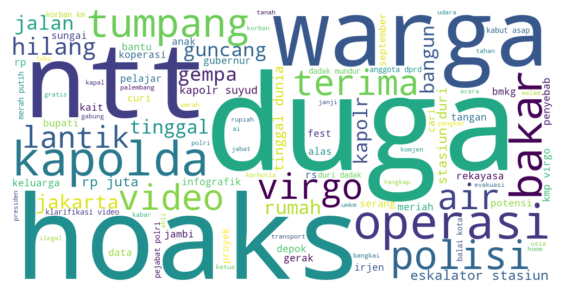

In [56]:
#Visualisasi Wordcloud setelah Preprocessing
text = ' '.join(df['rm_stopwords'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [57]:
#Rename Kolom
df.rename(columns={'rm_stopwords': 'Prepro'}, inplace=True)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Judul       138 non-null    str  
 1   Kategori    128 non-null    str  
 2   Link        138 non-null    str  
 3   Tanggal     101 non-null    str  
 4   rm_html     138 non-null    str  
 5   rm_hashtag  138 non-null    str  
 6   lower_case  138 non-null    str  
 7   rm_url      138 non-null    str  
 8   rm_punc     138 non-null    str  
 9   stem        138 non-null    str  
 10  Prepro      138 non-null    str  
dtypes: str(11)
memory usage: 12.0 KB


In [59]:
df[['Judul','Prepro','Kategori','Link','Tanggal']]

,Judul,Prepro,Kategori,Link,Tanggal
0,2 Pria Diduga Mesum di Toilet Stasiun Manggara...,2 pria duga mesum toilet stasiun manggarai tan...,Megapolitan,https://megapolitan.kompas.com/read/2026/10/04...,4 Oktober 2026
1,Kapolda NTT Irjen Rudi Darmoko Jabat Kalemdikl...,kapolda ntt irjen rudi darmoko jabat kalemdikl...,Nasional,https://nasional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
2,Eks Kapolda Riau Herry Heryawan Naik Pangkat J...,eks kapolda riau herry heryawan pangkat komjen...,Regional,https://regional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
3,Operasi Gabungan TNI-Polri Semalam di Majaleng...,operasi gabung tnipolri malam majalengka sita ...,Bandung,https://bandung.kompas.com/read/2026/10/04/103...,4 Oktober 2026
4,Heboh IRT Ketahuan Curi Cincin Berlian di Meda...,heboh irt curi cincin berlian medan modus simp...,Regional,https://regional.kompas.com/read/2026/10/04/10...,4 Oktober 2026
...,...,...,...,...,...
133,"BGN Bakal ""Cut Off"" Yayasan yang Pungut Setora...",bgn cut off yayasan pungut setor mitra dapur mbg,Nasional,https://nasional.kompas.com/read/2026/10/03/18...,3 Oktober 2026
134,Bupati Bulungan Percepat Pembangunan Infrastru...,bupati bulungan cepat bangun infrastruktur bun...,Regional,https://regional.kompas.com/read/2026/10/03/18...,3 Oktober 2026
135,2 Pelajar Terseret Ombak di Pantai Citepus Suk...,2 pelajar seret ombak pantai citepus sukabum 1...,Bandung,https://bandung.kompas.com/read/2026/10/03/175...,3 Oktober 2026
136,"Pipa Diduga Bocor Tersenggol Proyek Trotoar, J...",pipa duga bocor senggol proyek trotoar jalan h...,Megapolitan,https://megapolitan.kompas.com/read/2026/10/03...,3 Oktober 2026


In [60]:
#Download csv hasil Pre-Processing
df[['Judul','Prepro','Kategori','Link','Tanggal']].to_csv('berita_kompas_prepro.csv', index=False)